# Hyperparameter Tuning with Optuna

## Dataset Description

The data consists of 48x48 pixel grayscale images of faces. The faces have been automatically registered so that the face is more or less centered and occupies about the same amount of space in each image.
- The task is to categorize each face based on the emotion shown in the facial expression in to one of seven categories
  - 0 = Angry,
  - 1 = Disgust,
  - 2 = Fear,
  - 3 = Happy,
  - 4 = Sad,
  - 5 = Surprise,
  - 6 = Neutral

- The training set consists of 28,709 examples. The public test set used for the leaderboard consists of 3,589 examples. The final test set, which was used to determine the winner of the competition, consists of another 3,589 examples.

- This dataset was prepared by Pierre-Luc Carrier and Aaron Courville, as part of an ongoing research project. They have graciously provided the workshop organizers with a preliminary version of their dataset to use for this contest.

Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import models
from keras.layers import Input, Dense, Dropout, Activation, PReLU, BatchNormalization
from keras.utils import plot_model

import warnings
warnings.filterwarnings('ignore')

In [ ]:
try:
  import optuna
except:
  !pip install optuna
  import optuna

In [ ]:
check_gpu = len(tf.config.list_physical_devices( 'GPU'))>0
check_gpu

True

In [ ]:
print("GPUs Available: ", tf.config.list_physical_devices('GPU'))

GPUs Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

Mon Nov 10 16:19:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Load data

In [ ]:
fer = pd.read_csv('/content/drive/MyDrive/eda/datasets/fer2013.csv')
fer.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [ ]:
fer.Usage.unique()

array(['Training', 'PublicTest', 'PrivateTest'], dtype=object)

In [ ]:
fer.columns

Index(['emotion', 'pixels', 'Usage'], dtype='object')

In [ ]:
fer = pd.read_csv('/content/drive/MyDrive/eda/datasets/fer2013.csv',
                  sep=r'[,\s]+',  # regex for comma or whitespace as separators
                  engine='python')  # python engine to enable regex separator
fer.head()


emotion  \
0 70  80  82  72  58  58  60  63  54  58  60  48  89  115 121 119 115 110 98  91  84  84  90  99  110 126 143 153 158 171 169 172 169 165 129 110 113 107 95  79  66  62  56  57  61  52  43  41  65  61  58  57  56  69  75  70  65  56  54  105 146 154 151 151 155 155 150 147 147 148 152 158 164 172 177 182 186 189 188 190 188 180 167 116 95  103 97  77  72  62  55  58  54  56  52  44  50  43  54  64  63  71  68  64  52  66  119 156 161 164 163 164 167 168 170 174 175 176 178 179 183 187 190 195 197 198 197 198 195 191 190 145 86  100 90  65  57  60  54  51  41  49  56  47  38  44  63  55  46  52  54  55  83  138 157 158 165 168 172 171 173 176 179 179 180 182 185 187 189 189 192 197 200 199 196 198 200 198 197 177 91  87  96  58  58  59  51  42  37  41  47  45  37  35  36  30  41  47  59  94  141 159 161 161 164 170 171 172 176 178 179 182 183 183 187 189 192 192 194 195 200 200 199 199 200 201 197 193 111 71  108 69  55  61  51  42  43  56  54  44  24  29  31  45  61  72  100 136 150 159 163 162 163 170 172 171 174 177 177 180 187 186 187 189 192 192 194 195 196 197 199 200 201 200 197 201 137 58  98  92  57  62  53  47  41  40  51  43  24  35  52  63  75  104 129 143 149 158 162 164 166 171 173 172 174 178 178 179 187 188 188 191 193 194 195 198 199 199 197 198 197 197 197 201 164 52  78  87  69  58  56  50  54  39  44  42  26  31  49  65  91  119 134 145 147 152 159 163 167 171 170 169 174 178 178 179 187 187 185 187 190 188 187 191 197 201 199 199 200 197 196 197 182 58  62  77  61  60  55  49  59  52  54  44  22  30  47  68  102 123 136 144 148 150 153 157 167 172 173 170 171 177 179 178 186 190 186 189 196 193 191 194 190 190 192 197 201 203 199 194 189 69  48  74  56  60  57  50  59  59  51  41  20  34  47  79  111 132 139 143 145 147 150 151 160 169 172 171 167 171 177 177 174 180 182 181 192 196 189 192 198 195 194 196 198 201 202 195 189 70  39  69  61  61  61  53  59  59  45  40  26  40  61  93  124 135 138 142 144 146 151 152 158 165 168 168 165 161 164 173 172 167 172 167 180 198 198 193 199 195 194 198 200 198 197 195 190 65  35  68  59  59  62  57  60  59  50  44  32  54  90  115 132 137 138 140 144 146 146 156 165 168 174 176 176 175 168 168 169 171 175 171 172 192 194 184 198 205 201 194 195 193 195 192 186 57  38  72  65  57  62  58  57  60  54  49  47  79  116 130 138 141 141 139 141 143 145 157 164 164 166 173 174 176 179 179 176 181 189 188 173 180 175 160 182 189 198 192 189 190 190 188 172 46  44  64  66  59  62  57  56  62  53  50  66  103 133 137 141 143 141 136 132 131 136 127 118 111 107 108 123 131 143 154 158 166 177 181 175 170 159 148 171 161 176 185 192 194 188 190 162 53  49  58  63  61  61  55  56  61  51  50  81  116 139 142 142 146 144 136 128 119 112 97  85  90  91  88  92  90  80  81  84  106 122 132 144 145 144 147 163 147 163 173 181 190 187 191 167 61  48  53  61  61  58  54  56  61  51  53  89  123 140 144 145 146 147 136 122 107 99  95  92  90  87  83  76  67  52  46  52  63  69  83  96  119 132 148 159 136 137 143 138 143 152 156 156 70  48  50  59  61  57  54  54  61  52  56  93  124 135 140 144 148 150 140 125 114 101 80  54  56 54  41  41  33  40  39  35  49  60  63  74  107 129 147 147 116 111 100 77  76  86  108 111 73  49  50  60  62  60  57  55  63  59  56  89  121 134 139 146 151 152 150 141 127 111 96  77  85  70  32  31  37  91  65  50  48  59  73  83  112 136 155 130 60  46  38  40 43  81  116 91  72  52  48  58  62  62  59  53  61  59  52  85  114 134 140 147 154 159 158 153 145 143 150 126 121 125 68  45  89  137 95  70  78  75  95  109 131 153 171 94  23  16  32  82 82  65  113 77  71  54  48  56  62  62  60  53  60  56  52  75  108 133 141 149 158 166 169 167 163 156 155 146 112 119 134 127 142 140 121 117 129 114 120 129 146 174 191 98  46  33  33  109 147 98  109 67  73  55  50  56  64  64  61  58  61  53  54  64  106 129 140 148 159 169 175 176 174 165 159 156 145 120 115 124 127 131 133 141 147 142 141 147 161 182 202 154 114 96  100 158 158 153 123 61  76

In [ ]:
fer = fer.reset_index()
fer.head()

,level_0,level_1,level_2,level_3,level_4,level_5,level_6,level_7,level_8,level_9,...,level_2296,level_2297,level_2298,level_2299,level_2300,level_2301,level_2302,emotion,pixels,Usage
0,0,70,80,82,72,58,58,60,63,54,...,182,183,136,106,116,95,106,109,82,Training
1,0,151,150,147,155,148,133,111,140,170,...,108,95,108,102,67,171,193,183,184,Training
2,2,231,212,156,164,174,138,161,173,182,...,138,152,122,114,101,97,88,110,152,Training
3,4,24,32,36,30,32,23,19,20,30,...,126,132,132,133,136,139,142,143,142,Training
4,6,4,0,0,0,0,0,0,0,0,...,34,31,31,31,27,31,30,29,30,Training


In [ ]:
col_names = []
for i in range(fer.shape[1]):
  col_names.append(f'pixel_{i}')

In [ ]:
col_names[0] = 'emotion'
col_names[-1] = 'usage'
fer.columns = col_names
fer.head()

,emotion,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_2296,pixel_2297,pixel_2298,pixel_2299,pixel_2300,pixel_2301,pixel_2302,pixel_2303,pixel_2304,usage
0,0,70,80,82,72,58,58,60,63,54,...,182,183,136,106,116,95,106,109,82,Training
1,0,151,150,147,155,148,133,111,140,170,...,108,95,108,102,67,171,193,183,184,Training
2,2,231,212,156,164,174,138,161,173,182,...,138,152,122,114,101,97,88,110,152,Training
3,4,24,32,36,30,32,23,19,20,30,...,126,132,132,133,136,139,142,143,142,Training
4,6,4,0,0,0,0,0,0,0,0,...,34,31,31,31,27,31,30,29,30,Training


Segregate the data into Train, and Testing

In [ ]:
data_train = fer[fer['usage'] == 'Training']
data_val = fer[fer['usage'] == 'PrivateTest']
data_test = fer[fer['usage'] == 'PublicTest']

In [ ]:
X_train = data_train.drop(['emotion', 'usage'], axis = 1)
y_train = data_train['emotion']
X_train.shape, y_train.shape

((28709, 2304), (28709,))

In [ ]:
X_test = data_test.drop(['emotion', 'usage'], axis = 1)
y_test = data_test['emotion']
X_test.shape, y_test.shape

((3589, 2304), (3589,))

In [ ]:
X_val = data_val.drop(['emotion', 'usage'], axis = 1)
y_val = data_val['emotion']
X_val.shape, y_val.shape

((3589, 2304), (3589,))

In [ ]:
# Emotion dictionary
label_dict = {0: 'Angry',
              1: 'Disgust',
              2: 'Fear',
              3: 'Happy',
              4: 'Sad',
              5: 'Surprise',
              6: 'Neutral'}
label_dict

{0: 'Angry',
 1: 'Disgust',
 2: 'Fear',
 3: 'Happy',
 4: 'Sad',
 5: 'Surprise',
 6: 'Neutral'}

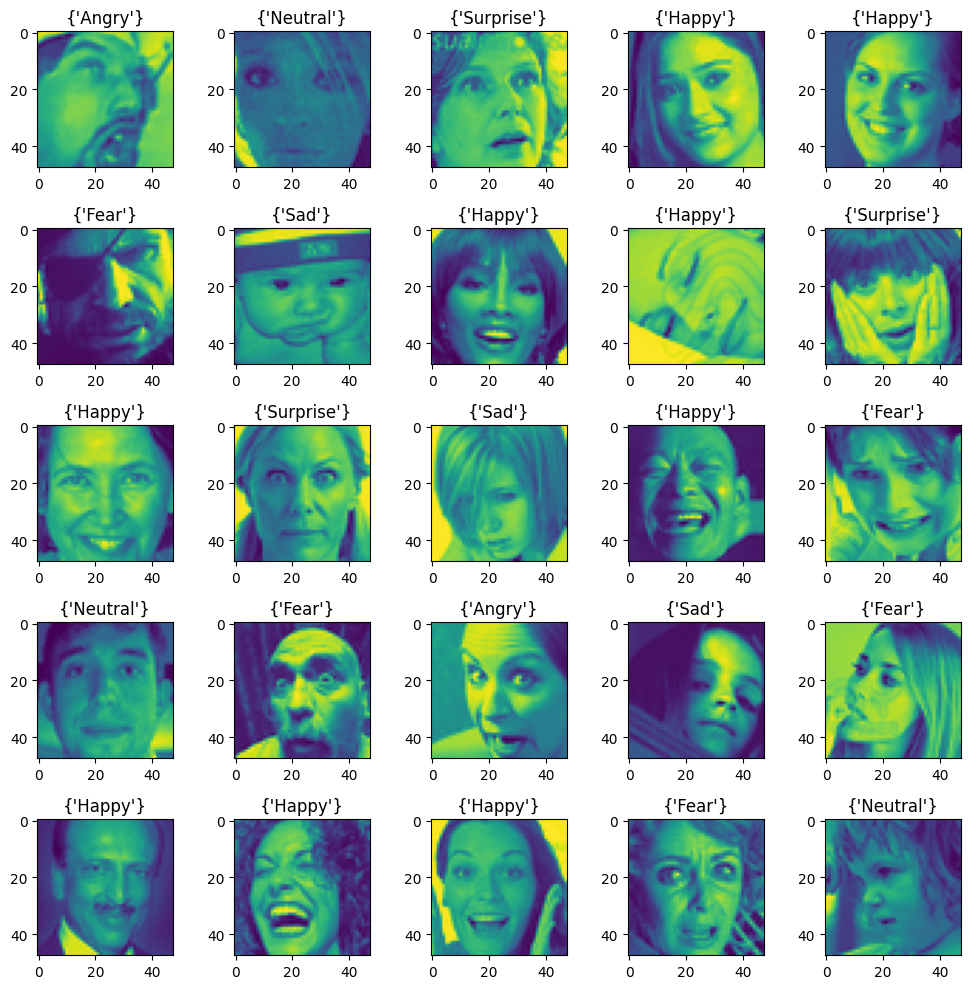

In [ ]:
fig, ax = plt.subplots(5, 5, figsize = (10, 10))
axs = ax.flatten()
for axis in axs:
  samp = data_train.sample(n = 1)
  axis.imshow(samp.values[:, 1:-1].reshape(48, 48).astype('uint8'))
  axis.set_title({label_dict[int(samp['emotion'].values)]})
plt.tight_layout()
plt.show()

#### Data Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler().set_output(transform = 'pandas')
X_train_transformed = scaler.fit_transform(X_train)
X_train_transformed.head()

,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,...,pixel_2295,pixel_2296,pixel_2297,pixel_2298,pixel_2299,pixel_2300,pixel_2301,pixel_2302,pixel_2303,pixel_2304
0,-0.609882,-0.459222,-0.403249,-0.507367,-0.672987,-0.666437,-0.641287,-0.610882,-0.759125,-0.734837,...,0.693322,1.008915,1.011680,0.352092,-0.062565,0.067986,-0.216423,-0.086296,-0.057375,-0.411277
1,0.372362,0.404616,0.411018,0.553296,0.503082,0.337040,0.055831,0.464802,0.889874,0.936669,...,-0.079703,-0.029926,-0.206637,-0.029433,-0.116214,-0.581221,0.778775,1.038743,0.891405,0.886669
2,1.342480,1.169730,0.523762,0.668308,0.842835,0.403938,0.739280,0.925809,1.060460,1.311317,...,-0.094018,0.391226,0.582500,0.161329,0.044732,-0.130751,-0.190233,-0.319063,-0.044553,0.479470
3,-1.167700,-1.051568,-0.979500,-1.044089,-1.012740,-1.134726,-1.201715,-1.211589,-1.100297,-0.979799,...,0.908051,0.222765,0.305610,0.297588,0.299564,0.332968,0.359744,0.379237,0.378551,0.352221
4,-1.410230,-1.446465,-1.430478,-1.427461,-1.430898,-1.442459,-1.461426,-1.490987,-1.526762,-1.570590,...,-1.411025,-1.068767,-1.092686,-1.078627,-1.068480,-1.111186,-1.054484,-1.069089,-1.083083,-1.072975


In [ ]:
X_val_transformed = scaler.transform(X_val)
X_val_transformed.head()

,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,...,pixel_2295,pixel_2296,pixel_2297,pixel_2298,pixel_2299,pixel_2300,pixel_2301,pixel_2302,pixel_2303,pixel_2304
32298,0.602765,0.009719,-0.165233,-0.302902,-0.280964,-0.438982,-0.395245,-0.345453,-0.588539,-0.504285,...,1.423402,1.401990,1.551615,1.523918,1.251830,1.048421,0.818059,0.599072,0.250338,0.212246
32299,-1.373850,-1.384763,-1.330261,-1.350787,-1.339426,-1.402319,-1.434088,-1.407168,-1.455685,-1.512952,...,-0.995881,-1.026652,-0.469683,-0.301951,-0.357634,-0.302989,-0.386654,-0.525967,-0.724085,-0.793026
32300,1.354606,1.515265,1.588573,1.626738,1.666083,1.701767,1.901143,0.143494,-1.185590,-1.224761,...,-0.666630,-1.251266,-0.289704,-0.574469,-0.867297,-0.581221,-1.434230,-1.405307,-1.403617,-1.340199
32301,0.966559,0.984622,0.436072,0.348831,0.607621,-0.251667,0.055831,-0.680732,-0.645401,-0.201684,...,0.449962,0.714109,1.039369,1.019760,-0.049153,0.465459,0.425218,0.469758,-1.031798,-1.454724
32302,-0.973677,-1.100930,-1.017081,-0.711833,-0.842864,-1.000929,-1.037687,-0.401333,0.633994,1.224860,...,-1.224926,-1.181075,-1.120375,-1.146756,-1.108717,-1.137684,-1.146147,-1.146678,-1.083083,-1.123875


### Build a model

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Create a model
seq_model = models.Sequential()
seq_model.add(Input(shape = (X_train.shape[1],)))
seq_model.add(Dense(units = 1024, activation="relu"))
seq_model.add(Dropout(0.4))
seq_model.add(Dense(units = 512, activation="relu"))
seq_model.add(Dropout(0.3))
seq_model.add(Dense(units = 256, activation="relu"))
seq_model.add(Dropout(0.2))
seq_model.add(Dense(units = 7))
seq_model.add(Activation('softmax'))

In [ ]:
seq_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,018,247 (11.51 MB)

 Trainable params: 3,018,247 (11.51 MB)

 Non-trainable params: 0 (0.00 B)

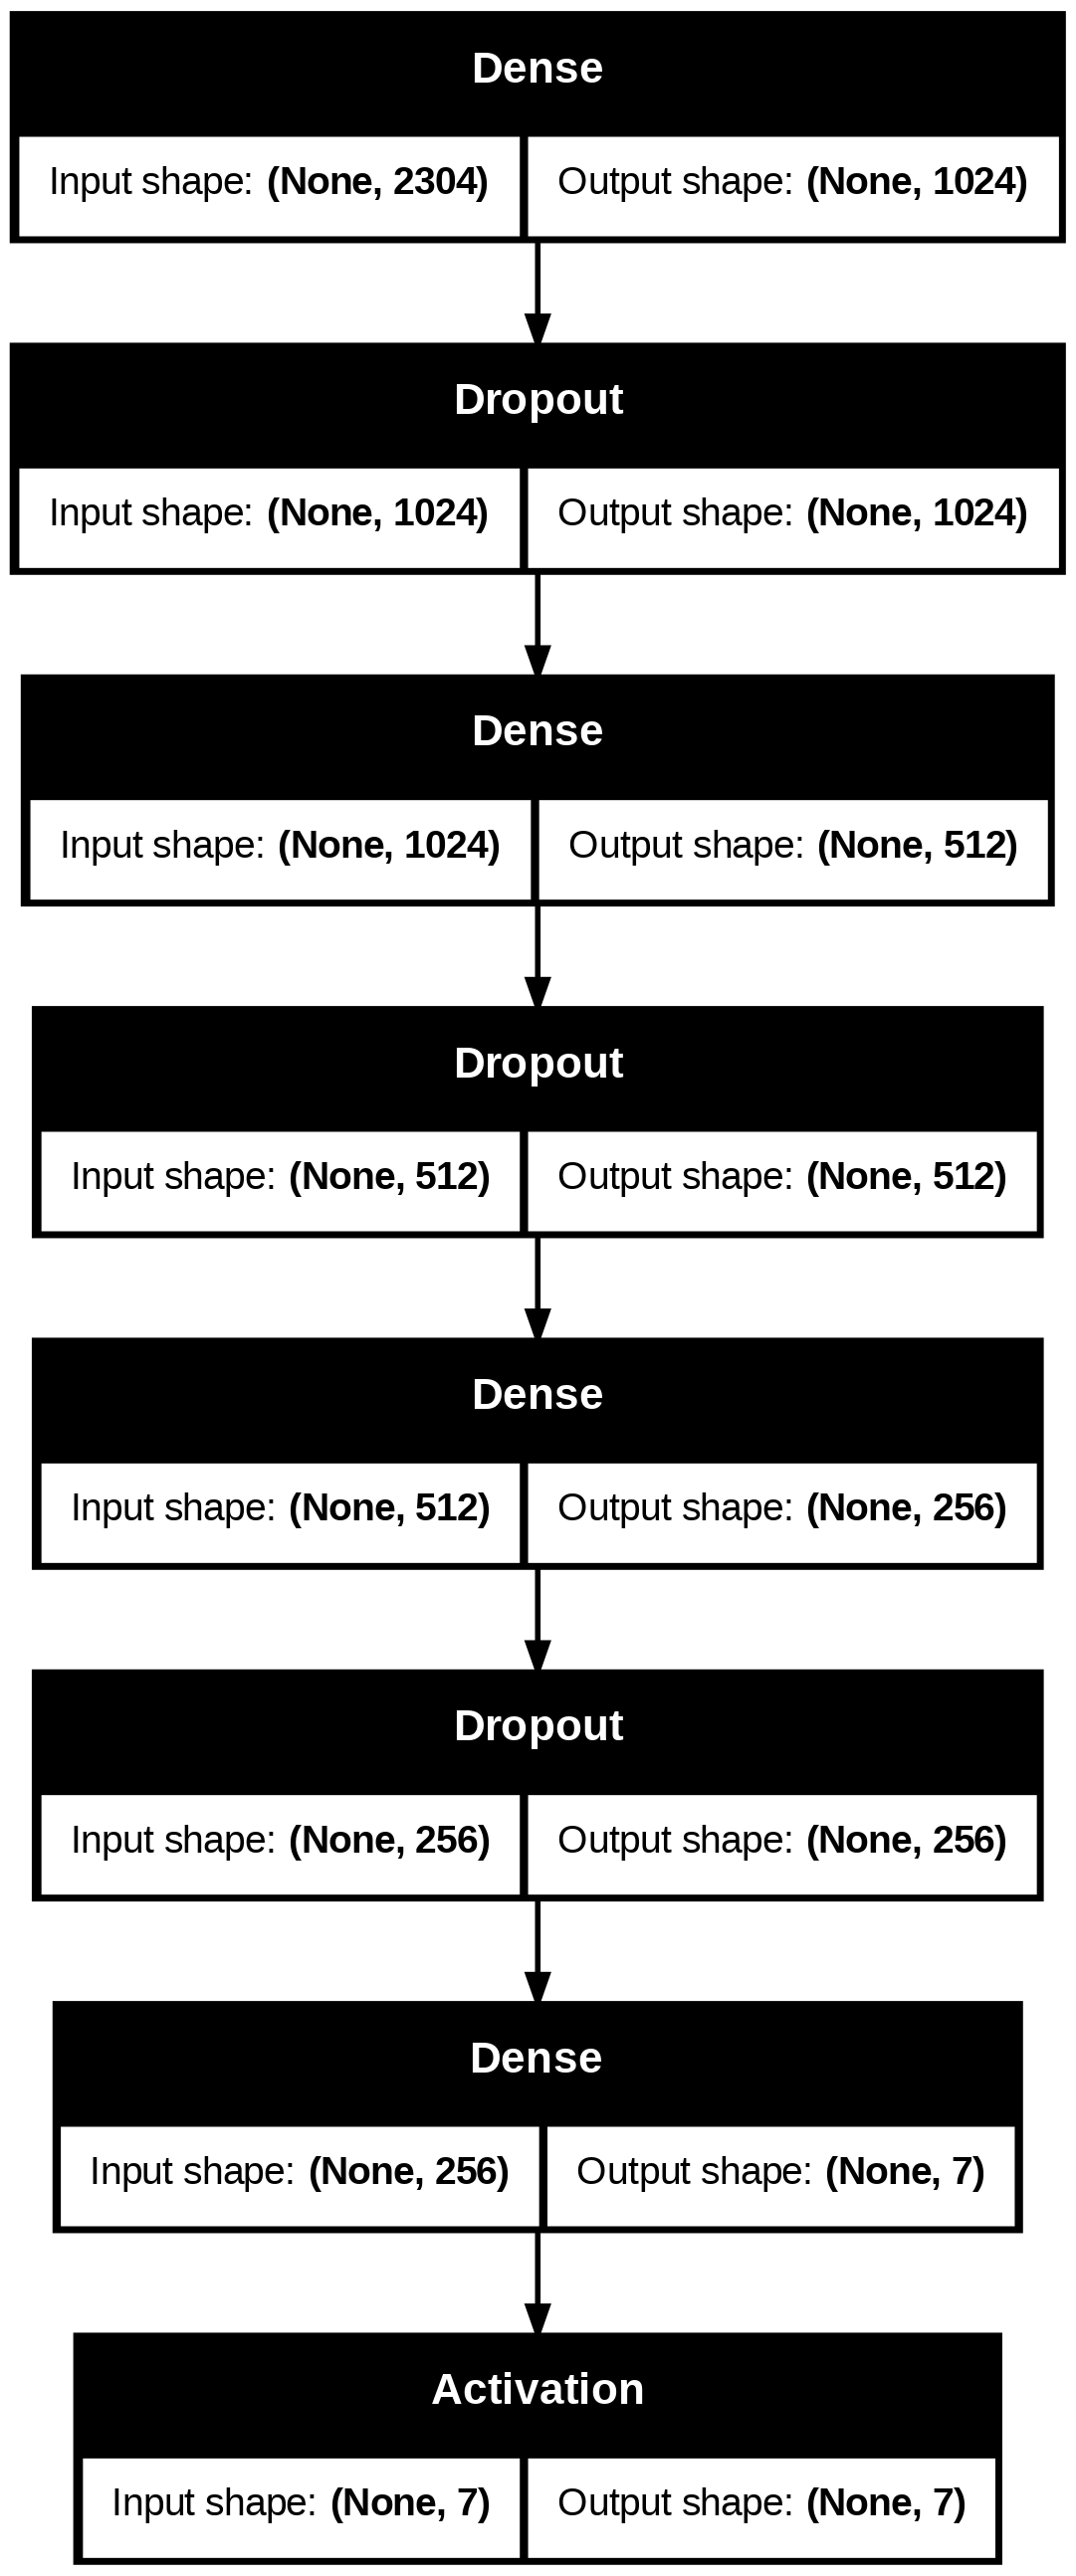

In [ ]:
plot_model(seq_model, show_shapes = True)

In [ ]:
seq_model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [ ]:
history = seq_model.fit(x = X_train_transformed,
                        y = y_train,
                        validation_data = (X_val, y_val),
                        shuffle = True,
                        epochs = 10)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - accuracy: 0.2446 - loss: 2.0891 - val_accuracy: 0.2797 - val_loss: 61.8338
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.3256 - loss: 1.6999 - val_accuracy: 0.2003 - val_loss: 35.3683
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - accuracy: 0.3376 - loss: 1.6655 - val_accuracy: 0.2761 - val_loss: 41.7974
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.3440 - loss: 1.6523 - val_accuracy: 0.2942 - val_loss: 49.1602
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.3496 - loss: 1.6317 - val_accuracy: 0.2912 - val_loss: 49.1360
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.3599 - loss: 1.6160 - val_accuracy: 0.2159 - val_loss: 68.2367
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.3635 - loss: 1.6095 - val_accuracy: 0.2421 - val_loss: 59.3834
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.3644 - loss: 1.

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

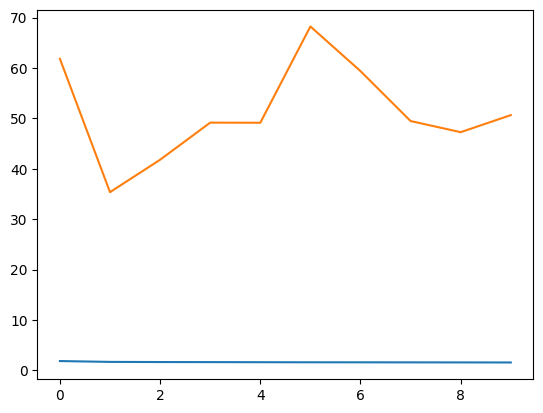

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
seq_model.evaluate(x= X_test, y = y_test)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2542 - loss: 51.1415


[52.300785064697266, 0.2460295408964157]

### Define an objective

In [ ]:
def create_model(trial):
    # Define hyperparameters
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch = trial.suggest_categorical('batch_size', [16, 32, 64, 128, 256])

    regularizer_name = trial.suggest_categorical('regularization', ['l1', 'l2', 'l1_l2'])

    # Function to create regularizer based on choice
    def regularize(name):
        if name == 'l1':
            return keras.regularizers.L1(0.01)
        elif name == 'l2':
            return keras.regularizers.L2(0.01)
        else:
            return keras.regularizers.L1L2(l1=0.01, l2=0.01)
    # Instantiate chosen regularizer
    chosen_regularizer = regularize(regularizer_name)

    # Suggest activation function as a string
    activation_name = trial.suggest_categorical('activation_function', ['prelu', 'swish', 'relu'])

    # Function to create activation layer based on choice
    def get_activation_layer(name):
        if name == 'prelu':
            return PReLU()
        elif name == 'swish':
            return keras.layers.Activation('swish')
        else:
            return keras.layers.Activation('relu')

    # Define model
    model = keras.Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(units=1024, kernel_regularizer=chosen_regularizer),
        BatchNormalization(),
        get_activation_layer(activation_name),
        Dropout(dropout_rate),
        Dense(units=512, kernel_regularizer=chosen_regularizer),
        BatchNormalization(),
        get_activation_layer(activation_name),
        Dropout(dropout_rate),
        Dense(units=256, kernel_regularizer=chosen_regularizer),
        BatchNormalization(),
        get_activation_layer(activation_name),
        Dropout(dropout_rate),
        Dense(units=7),
        Activation('softmax')
    ])

    # Compile model
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Early stopping callback
    callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # Train the model
    history = model.fit(
        X_train_transformed, y_train,
        validation_data=(X_val_transformed, y_val),
        batch_size=batch,
        epochs=10,
        verbose=0,
        callbacks=[callback])
    return history


In [ ]:
def objective(trial):
    # Use GPU explicitly (important when multiple GPUs)
    with tf.device('/GPU:0'):
        history = create_model(trial)

        # Return validation accuracy as Optuna metric
        val_acc = history.history['val_accuracy'][-1]
        tf.keras.backend.clear_session()  # free GPU memory
        return val_acc

# Run study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best hyperparameters:", study.best_trial.params)

[I 2025-11-10 16:32:45,676] A new study created in memory with name: no-name-0a2c6515-e118-49f6-b6c6-a19aef4ba8ce
[I 2025-11-10 16:33:10,825] Trial 0 finished with value: 0.2800222933292389 and parameters: {'dropout_rate': 0.4591302464812095, 'lr': 0.003356849909786325, 'batch_size': 128, 'regularization': 'l2', 'activation_function': 'prelu'}. Best is trial 0 with value: 0.2800222933292389.
[I 2025-11-10 16:33:40,621] Trial 1 finished with value: 0.4062412977218628 and parameters: {'dropout_rate': 0.39888900321953014, 'lr': 0.0001132851333692805, 'batch_size': 64, 'regularization': 'l2', 'activation_function': 'swish'}. Best is trial 1 with value: 0.4062412977218628.
[I 2025-11-10 16:34:30,843] Trial 2 finished with value: 0.23683477938175201 and parameters: {'dropout_rate': 0.4796776131267003, 'lr': 0.0003163603785967454, 'batch_size': 32, 'regularization': 'l1_l2', 'activation_function': 'relu'}. Best is trial 1 with value: 0.4062412977218628.
[I 2025-11-10 16:35:22,206] Trial 3 fin

Best hyperparameters: {'dropout_rate': 0.2978961837741498, 'lr': 0.00010844490510737661, 'batch_size': 64, 'regularization': 'l2', 'activation_function': 'swish'}


ReLU
{'dropout_rate': 0.15696010124174922, 'lr': 0.00017871451344805454, 'batch_size': 256}. Best is trial 23 with value: 0.46001672744750977.

Swish
{'dropout_rate': 0.2688565851756515, 'lr': 0.0001892213748457019, 'batch_size': 128}. Best is trial 9 with value: 0.47199776768684387.

{'dropout_rate': 0.2803914341830359, 'lr': 0.00014767858415311948, 'batch_size': 64, 'activation_function': 'swish'}. Best is trial 27 with value: 0.465589314699173.

BN {'dropout_rate': 0.17886079020053877, 'lr': 0.00039335266353532594, 'batch_size': 32, 'activation_function': 'prelu'}. Best is trial 9 with value: 0.4583449363708496.

BN {'dropout_rate': 0.2978961837741498, 'lr': 0.00010844490510737661, 'batch_size': 64, 'regularization': 'l2', 'activation_function': 'swish'}. Best is trial 13 with value: 0.4196154773235321.

<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

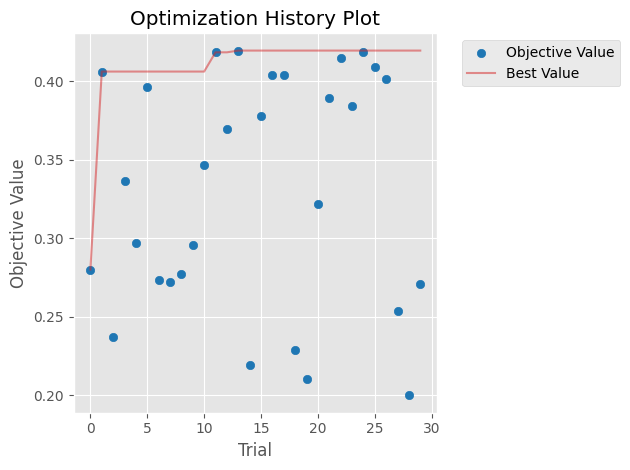

In [ ]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
fig

<Axes: title={'center': 'Contour Plot'}, xlabel='dropout_rate', ylabel='lr'>

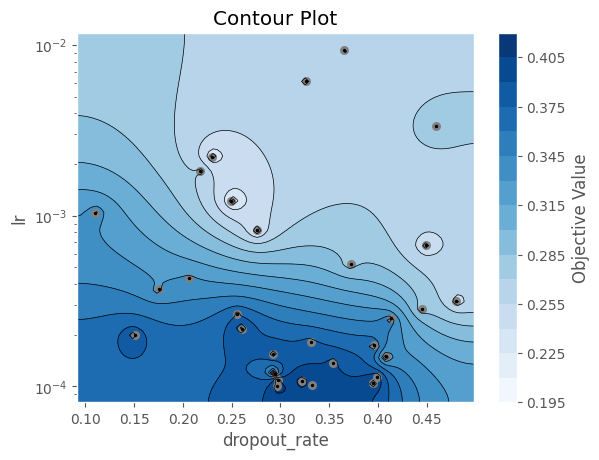

In [ ]:
optuna.visualization.matplotlib.plot_contour(study, params=['dropout_rate', 'lr'])

<Axes: title={'center': 'Contour Plot'}, xlabel='batch_size', ylabel='regularization'>

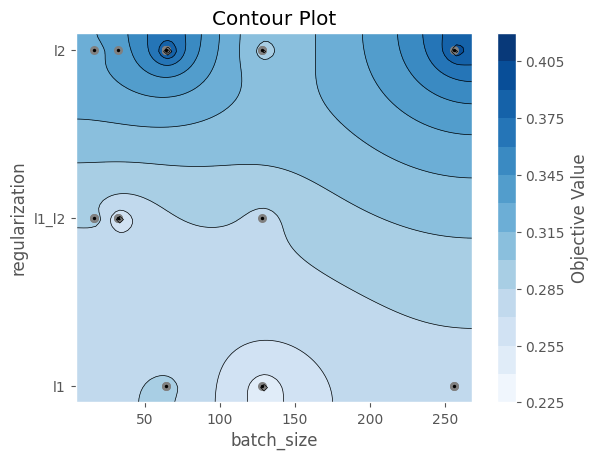

In [ ]:
optuna.visualization.matplotlib.plot_contour(study, params=['batch_size', 'regularization'])

<Axes: title={'center': 'Contour Plot'}, xlabel='activation_function', ylabel='regularization'>

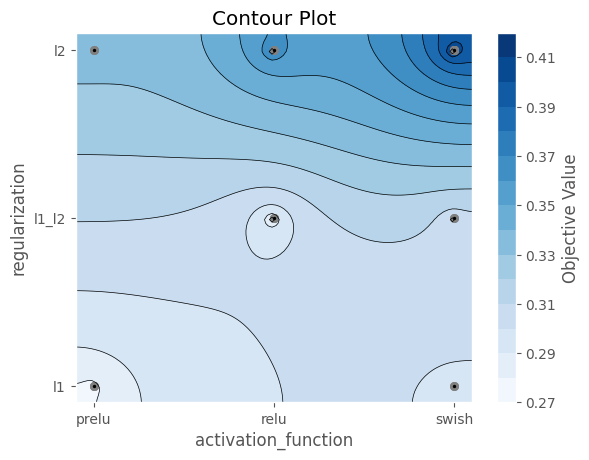

In [ ]:
optuna.visualization.matplotlib.plot_contour(study, params=['regularization', 'activation_function'])

<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

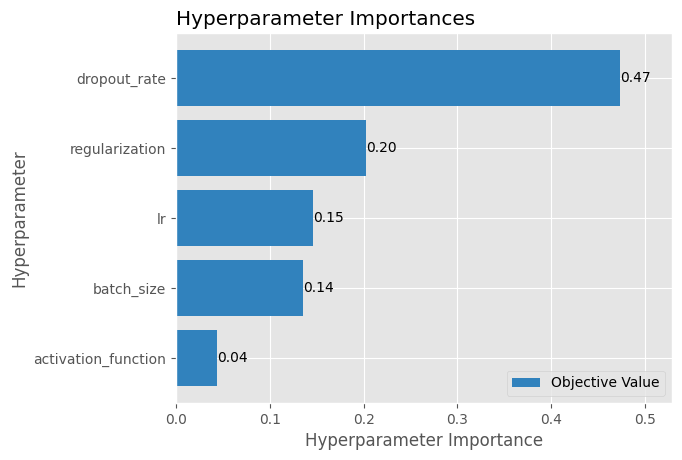

In [ ]:
optuna.visualization.matplotlib.plot_param_importances(study, params=['dropout_rate', 'lr', 'batch_size', 'regularization', 'activation_function'])

<Axes: title={'center': 'Parallel Coordinate Plot'}>

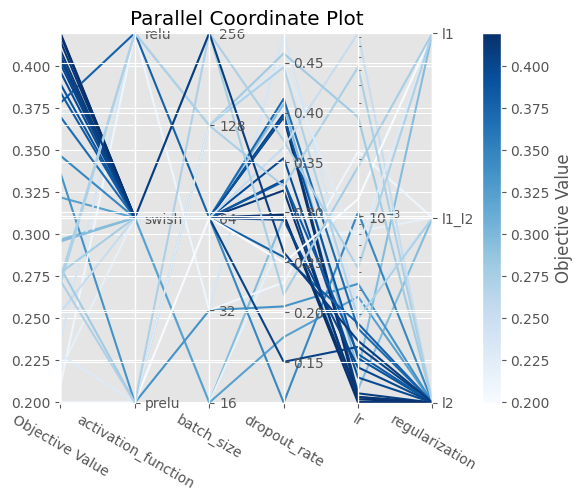

In [ ]:
optuna.visualization.matplotlib.plot_parallel_coordinate(study, params=['dropout_rate', 'lr', 'batch_size', 'regularization', 'activation_function'])

<Axes: title={'center': 'Empirical Distribution Function Plot'}, xlabel='Objective Value', ylabel='Cumulative Probability'>

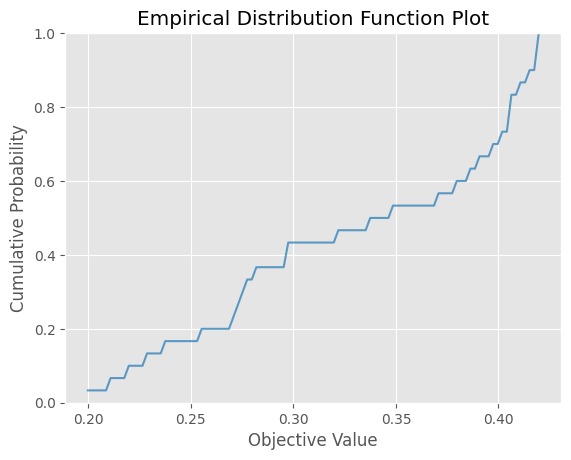

In [ ]:
optuna.visualization.matplotlib.plot_edf(study)